# Hyperelastic Material Constitutive Law Curve Fitting

This notebook replicates the core curve-fitting functionality from the Soft Robotics Materials Database app. It fits hyperelastic constitutive models to uniaxial tensile test data from CSV files. This notebook is created with help from GitHub Copilot, mostly a combination of Grok Code and Claude Haiku.

## Overview
- **Section 1**: Import experimental data from CSV files
- **Section 2**: Perform curve fitting and optimization with selected constitutive models
- **Section 3**: Output processed data and results

## Section 1: Import Data

In this section, we import the experimental data from a CSV file. The CSV should contain uniaxial tensile test data with columns for True Strain, True Stress, Engineering Strain, and Engineering Stress.

**Instructions:**
1. Set the `csv_file_path` variable to the path of your CSV file
2. Run the cell to load the data

In [2]:
# Section 1: Import Data

import pandas as pd
import numpy as np
from scipy.optimize import least_squares, minimize, NonlinearConstraint, LinearConstraint
from Hyperelastic import Hyperelastic
from HyperelasticStats import HyperelasticStats
import os

# User input: Set the path to your CSV file. If the test data is in a different directory than this notebook,
# remove the "os.path.{...}" and enter the full directory within the quotation marks
csv_file_path = os.path.join(os.getcwd(), "Tensile-Tests-Data/Ecoflex 00-30.csv")

def read_csv_exp_data_files(file_path):
    """Read experimental data from CSV file."""
    try:
        # Read header information
        header = pd.read_csv(file_path, delimiter=';', usecols=["PARAMETER", "INFO", "URL"]).head(15)
        # Read experimental data (skipping header rows)
        data = pd.read_csv(file_path, delimiter=';', skiprows=18,
                          names=['Time (s)', 'True Strain', 'True Stress (MPa)',
                                'Engineering Strain', 'Engineering Stress (MPa)'])
        return data, header
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        raise

# Load the data
print(f"Reading data from {csv_file_path}...")
data, header = read_csv_exp_data_files(csv_file_path)
print("Data loaded successfully!")
print(f"Number of data points: {len(data)}")
print(f"Strain range: {data['True Strain'].min():.3f} to {data['True Strain'].max():.3f}")
print(f"Stress range: {data['True Stress (MPa)'].min():.3f} to {data['True Stress (MPa)'].max():.3f} MPa")

Reading data from g:\Coding\materials-venv\Soft-Robotics-Materials-Database\Tensile-Tests-Data/Ecoflex 00-30.csv...
Data loaded successfully!
Number of data points: 705
Strain range: 0.066 to 2.837
Stress range: 0.002 to 23.204 MPa


## Section 2: Curve Fitting and Optimization

In this section, we select constitutive models and perform the curve fitting optimization.

**Available Models:**
- Mooney Rivlin
- Ogden
- Neo Hookean
- Yeoh
- Gent
- Veronda Westmann
- Humphrey

**Instructions:**
1. Set the desired models, order, data type, and strain range
2. Run the cell to perform fitting

In [23]:
# Section 2: Curve Fitting and Optimization

def objectiveFun_Callback(parameters, exp_strain, exp_stress, hyperelastic):
    """Cost function for optimization."""
    theo_stress = hyperelastic.ConsitutiveModel(parameters, exp_strain)
    if hyperelastic.fitting_method == 'lm':
        residuals = theo_stress - exp_stress
    elif hyperelastic.fitting_method == 'trust-constr':
        residuals = np.sqrt(sum((theo_stress - exp_stress)**2.0))
    else:
        raise ValueError("Error: please choose either 'lm' or 'trust-constr' as fitting method")
    return residuals

def optimization(model, order, dataframe, data_type, strain_range=None):
    """Perform optimization to fit constitutive model to experimental data."""
    hyperelastic = Hyperelastic(model, np.array([0]), order, data_type)
    
    # Select data within strain range if specified
    if strain_range:
        min_strain, max_strain = strain_range
        mask = (dataframe[data_type + ' Strain'] >= min_strain) & (dataframe[data_type + ' Strain'] <= max_strain)
        dataframe = dataframe[mask]
    
    exp_strain = dataframe[data_type + ' Strain'].values
    exp_stress = dataframe[data_type + ' Stress (MPa)'].values
    
    if hyperelastic.fitting_method == 'trust-constr':
        if hyperelastic.model == 'Ogden':
            const = NonlinearConstraint(hyperelastic.NonlinearConstraintFunction, 0.0, np.inf,
                                      jac=hyperelastic.NonlinearConstraintJacobian, hess='2-point')
        elif hyperelastic.model == 'Mooney Rivlin':
            const = LinearConstraint([[1.0, 1.0, 0.0][:hyperelastic.order],
                                    [0.0, 0.0, 0.0][:hyperelastic.order]], 0.0, np.inf)
        else:
            const = ()
        
        optim_result = minimize(objectiveFun_Callback, hyperelastic.initialGuessParam,
                              args=(exp_strain, exp_stress, hyperelastic),
                              method='trust-constr', constraints=const, tol=1e-12)
    elif hyperelastic.fitting_method == 'lm':
        optim_result = least_squares(objectiveFun_Callback, hyperelastic.initialGuessParam,
                                   method='lm', gtol=1e-12,
                                   args=(exp_strain, exp_stress, hyperelastic))
    else:
        raise ValueError("Error in fitting method")
    
    optim_parameters = optim_result.x
    
    df_model_param = pd.DataFrame(optim_parameters, index=hyperelastic.param_names,
                                columns=[model]).transpose()
    
    theo_stress = hyperelastic.ConsitutiveModel(optim_parameters, exp_strain)
    data_model = pd.DataFrame({data_type + ' Strain': exp_strain,
                             data_type + ' Stress (MPa)': theo_stress})
    
    stats = HyperelasticStats(exp_stress, theo_stress, hyperelastic.nbparam)
    aic = stats.aic()
    r_squared = stats.r_squared()
    
    return df_model_param, data_model, aic, r_squared

# User inputs for fitting - alternating {"model name", order}
model_configs = ["Mooney Rivlin", 3, "Ogden", 3, "Neo Hookean", 1]
data_type = "True"  # "True" or "Engineering"
strain_range = None  # (min_strain, max_strain) or None for full range

# Parse model configurations
models_to_fit = [model_configs[i] for i in range(0, len(model_configs), 2)]
model_orders = {model_configs[i]: model_configs[i+1] for i in range(0, len(model_configs), 2)}

# Validate inputs
valid_models = ['Mooney Rivlin', 'Ogden', 'Neo Hookean', 'Yeoh', 'Gent', 'Veronda Westmann', 'Humphrey']
for model in models_to_fit:
    if model not in valid_models:
        raise ValueError(f"Invalid model '{model}'. Valid options: {', '.join(valid_models)}")

if data_type not in ['True', 'Engineering']:
    raise ValueError("data_type must be 'True' or 'Engineering'")

# Perform fitting for each model
results = {}
for model in models_to_fit:
    model_order = model_orders[model]
    print(f"Fitting {model} model (order {model_order}) to {data_type} data...")
    if strain_range:
        print(f"Using strain range: {strain_range[0]} to {strain_range[1]}")
    
    df_param, model_data, aic, r_squared = optimization(model, model_order, data, data_type, strain_range)
    
    results[model] = {
        'parameters': df_param,
        'fitted_data': model_data,
        'aic': aic,
        'r_squared': r_squared
    }
    
    print(f"Parameters:\n{df_param.to_string()}")

    print()

# Find best model based on AIC
best_model = min(results.keys(), key=lambda x: results[x]['aic'])
print(f"Best model based on AIC: {best_model}")

Fitting Mooney Rivlin model (order 3) to True data...
Parameters:
                    C10       C01       C20
Mooney Rivlin  0.013895 -0.013895  0.000048

Fitting Ogden model (order 3) to True data...


g:\Coding\materials-venv\Soft-Robotics-Materials-Database\.venv\Lib\site-packages\scipy\optimize\_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


Parameters:
             µ1        µ2        µ3        α1        α2        α3
Ogden  0.058631  0.002482  0.069098  0.268615  3.221085  0.330517

Fitting Neo Hookean model (order 1) to True data...
Parameters:
                    µ
Neo Hookean  0.064902

Best model based on AIC: Ogden


## Section 3: Output Processed Data

In this section, we save the fitted data and results to CSV files.

**Instructions:**
1. Set the output directory
2. Run the cell to save the results

In [12]:
# Section 3: Output Processed Data

# User input: Set the output directory
output_directory = "."  # Current directory, change to your desired path

# Ensure output directory exists
os.makedirs(output_directory, exist_ok=True)

# Save results for each model
for model, result in results.items():
    # Save fitted data
    fitted_file = os.path.join(output_directory, f"{os.path.splitext(os.path.basename(csv_file_path))[0]}_{model.replace(' ', '_')}_fitted.csv")
    result['fitted_data'].to_csv(fitted_file, index=False)
    print(f"Fitted data for {model} saved to: {fitted_file}")
    
    # Save comparison data
    comparison_data = pd.DataFrame({
        'Strain': data[data_type + ' Strain'],
        'Experimental_Stress': data[data_type + ' Stress (MPa)'],
        'Model_Stress': np.interp(data[data_type + ' Strain'], 
                                result['fitted_data'][data_type + ' Strain'], 
                                result['fitted_data'][data_type + ' Stress (MPa)'])
    })
    comparison_file = os.path.join(output_directory, f"{os.path.splitext(os.path.basename(csv_file_path))[0]}_{model.replace(' ', '_')}_comparison.csv")
    comparison_data.to_csv(comparison_file, index=False)
    print(f"Comparison data for {model} saved to: {comparison_file}")

# Save summary of all models
summary_data = []
for model, result in results.items():
    params_dict = result['parameters'].iloc[0].to_dict()
    summary_data.append({
        'Model': model,
        'AIC': result['aic'],
        'R_Squared': result['r_squared'],
        **params_dict
    })

summary_df = pd.DataFrame(summary_data)
summary_file = os.path.join(output_directory, f"{os.path.splitext(os.path.basename(csv_file_path))[0]}_model_summary.csv")
summary_df.to_csv(summary_file, index=False)
print(f"Model summary saved to: {summary_file}")

print("\nAll results saved successfully!")

Fitted data for Mooney Rivlin saved to: .\Ecoflex 00-30_Mooney_Rivlin_fitted.csv
Comparison data for Mooney Rivlin saved to: .\Ecoflex 00-30_Mooney_Rivlin_comparison.csv
Fitted data for Ogden saved to: .\Ecoflex 00-30_Ogden_fitted.csv
Comparison data for Ogden saved to: .\Ecoflex 00-30_Ogden_comparison.csv
Fitted data for Neo Hookean saved to: .\Ecoflex 00-30_Neo_Hookean_fitted.csv
Comparison data for Neo Hookean saved to: .\Ecoflex 00-30_Neo_Hookean_comparison.csv
Model summary saved to: .\Ecoflex 00-30_model_summary.csv

All results saved successfully!


## Visualization (Optional)

You can add plotting code here to visualize the results.

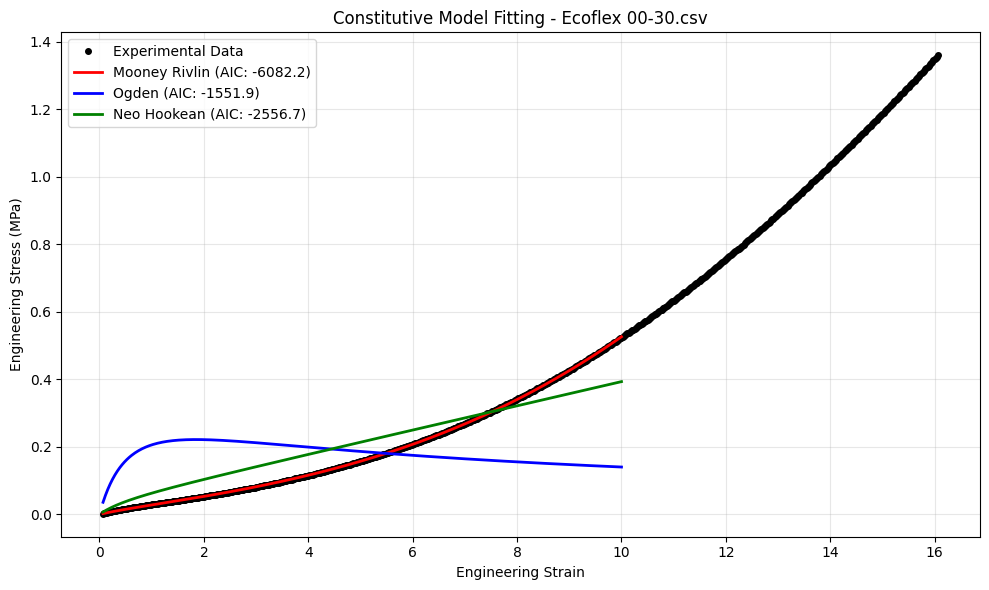

In [20]:
# Optional: Visualization
import matplotlib.pyplot as plt

# Plot experimental data and fitted models
plt.figure(figsize=(10, 6))
plt.plot(data[data_type + ' Strain'], data[data_type + ' Stress (MPa)'], 'ko', label='Experimental Data', markersize=4)

colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, (model, result) in enumerate(results.items()):
    color = colors[i % len(colors)]
    plt.plot(result['fitted_data'][data_type + ' Strain'], 
             result['fitted_data'][data_type + ' Stress (MPa)'], 
             color=color, linewidth=2, label=f'{model} (AIC: {result["aic"]:.1f})')

plt.xlabel(f'{data_type} Strain')
plt.ylabel(f'{data_type} Stress (MPa)')
plt.title(f'Constitutive Model Fitting - {os.path.basename(csv_file_path)}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()